In [1]:
import json
import os
import csv
import pandas as pd
import numpy as np
#from util.data_utils import clean_df

from data.ag.action_genome import ActionGenome, MultiAG, SingleAG, SingleBothAG
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import torch
import numpy as np

import matplotlib.pyplot as plt
from util.visualize import show_pyg_graph
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score, top_k_accuracy_score
from scipy.stats import entropy

In [2]:
import random
import json

# Create a list of integers from 0 to 10000
integer_list = list(range(8693))

# Randomize the order of the list
random.shuffle(integer_list)

# Dump the list into a file
with open('randomized_idxs.json', 'w') as f:
    json.dump(integer_list, f)


In [3]:
root = '/data/Datasets/ag/'
meta_root = 'data/ag/'
split = 'test'


ag = SingleAG(root, meta_root, no_img=False, position='pre', subset=True, split=split)
#ag = SingleBothAG(root, meta_root, subset=False, split=None)

/home/muyang/learned-affordance-constraints/util/data_utils.py:57: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  actions_split = split_df['actions'].str.split(';').apply(pd.Series, 1).stack()


Using all 4264 samples


In [43]:
print(list(enumerate(ag.verb_classes)))

[(0, 'awaken'), (1, 'close'), (2, 'cook'), (3, 'dress'), (4, 'drink'), (5, 'eat'), (6, 'fix'), (7, 'grasp'), (8, 'hold'), (9, 'lie'), (10, 'make'), (11, 'open'), (12, 'photograph'), (13, 'play'), (14, 'pour'), (15, 'put'), (16, 'run'), (17, 'sit'), (18, 'snuggle'), (19, 'stand'), (20, 'take'), (21, 'talk'), (22, 'throw'), (23, 'tidy'), (24, 'turn'), (25, 'undress'), (26, 'walk'), (27, 'wash'), (28, 'watch'), (29, 'work')]


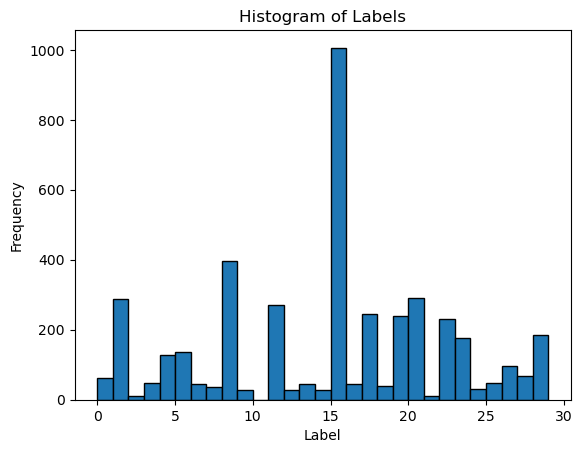

In [45]:
true_labels = np.argmax(labels, axis=1)

plt.hist(true_labels, bins=len(np.unique(true_labels)), edgecolor='black')
plt.title('Histogram of Labels')
plt.xlabel('Label')
plt.ylabel('Frequency')
plt.show()

In [74]:
labels = np.load("runs/vit_full/test_runs/test_1_combat/joint.npy")[:, 1]
joint_preds = np.load("runs/vit_full/test_runs/test_1_combat/joint.npy")[:, 0]
neural_preds = np.load("runs/vit_full/test_runs/test_1_combat/neural.npy")[:, 0]
rules_preds = np.load("runs/vit_full/test_runs/test_1_combat/rules.npy")[:, 0]

#labels = np.load("runs/mvit_full/test_runs/test_1_hospital/joint.npy")[:, 1]
#joint_preds = np.load("runs/mvit_full/test_runs/test_1_hospital/joint.npy")[:, 0]
#neural_preds = np.load("runs/mvit_full/test_runs/test_1_hospital/neural.npy")[:, 0]
#rules_preds = np.load("runs/mvit_full/test_runs/test_1_hospital/rules.npy")[:, 0]


act_classes_sorted = [15, 8, 17, 11, 19, 1, 20, 22, 28, 5, 26, 4, 23, 25, 13, 0, 27, 16, 18, 3, 6, 14, 29, 2, 24, 9, 7, 12, 21, 10]
bottom_half = act_classes_sorted[15:]
print([ag.verb_classes[i] for i in bottom_half])
#labels = labels[:, bottom_half]
#joint_preds = joint_preds[:, bottom_half]
#neural_preds = neural_preds[:, bottom_half]
#rules_preds = rules_preds[:, bottom_half]
#Remove all rows from all arrays where labels is all zeros
#non_zero_indices = np.any(labels != 0, axis=1)
#Get the true labels


true_labels = np.argmax(labels, axis=1)
# Get the predicted labels
joint_pred_labels = np.argmax(joint_preds, axis=1)
neural_pred_labels = np.argmax(neural_preds, axis=1)
rules_pred_labels = np.argmax(rules_preds, axis=1)

print(true_labels.shape)
bottom_half_indices = [i for i, label in enumerate(true_labels) if label in bottom_half]
print(len(bottom_half_indices))

#true_labels = true_labels[bottom_half_indices]
#joint_pred_labels = joint_pred_labels[bottom_half_indices]
#neural_pred_labels = neural_pred_labels[bottom_half_indices]
#rules_pred_labels = rules_pred_labels[bottom_half_indices]
#joint_preds = joint_preds[bottom_half_indices]
#neural_preds = neural_preds[bottom_half_indices]
#rules_preds = rules_preds[bottom_half_indices]

print(true_labels.shape)
true_labels_one_hot = np.eye(len(ag.verb_classes))[true_labels]

labels_vec = np.arange(len(ag.verb_classes))

def compute_metrics(true_labels, pred_labels, preds, model_name):
    # Compute F1 score
    f1 = f1_score(true_labels, pred_labels, average='macro', zero_division=0, labels=labels_vec)
    
    # Compute Precision score
    precision = precision_score(true_labels, pred_labels, average='macro', zero_division=0, labels=labels_vec)
    
    # Compute Recall score
    recall = recall_score(true_labels, pred_labels, average='macro', zero_division=0, labels=labels_vec)
    
    # Compute Accuracy and Top-k Accuracy
    accuracy = accuracy_score(true_labels, pred_labels)
    top3_acc = top_k_accuracy_score(true_labels, preds, k=3, labels=labels_vec)
    top5_acc = top_k_accuracy_score(true_labels, preds, k=5, labels=labels_vec)
    mean_entropy = entropy(preds.T, base=2, nan_policy='raise').mean()
    
    # Print metrics
    print(f"{model_name} \tAccuracy:        {accuracy}")
    print(f"{model_name} \tTop-3 Accuracy:  {top3_acc}")
    print(f"{model_name} \tTop-5 Accuracy:  {top5_acc}")
    print(f"{model_name} \tF1 Score:        {f1}")
    print(f"{model_name} \tPrecision:       {precision}")
    print(f"{model_name} \tRecall:          {recall}")
    print(f"{model_name} \tMean Entropy:    {mean_entropy}")

# Call the function for each model
compute_metrics(true_labels, joint_pred_labels, joint_preds, "Joint")
compute_metrics(true_labels, neural_pred_labels, neural_preds, "Neural")
compute_metrics(true_labels, rules_pred_labels, rules_preds, "Rules")

['awaken', 'wash', 'run', 'snuggle', 'dress', 'fix', 'pour', 'work', 'cook', 'turn', 'lie', 'grasp', 'photograph', 'talk', 'make']
(4264,)
510
(4264,)
Joint 	Accuracy:        0.3219981238273921
Joint 	Top-3 Accuracy:  0.6599437148217636
Joint 	Top-5 Accuracy:  0.8102720450281425
Joint 	F1 Score:        0.2223403137001956
Joint 	Precision:       0.23387277234945061
Joint 	Recall:          0.2437053028362806
Joint 	Mean Entropy:    1.5447334051132202
Neural 	Accuracy:        0.2926829268292683
Neural 	Top-3 Accuracy:  0.6024859287054409
Neural 	Top-5 Accuracy:  0.7495309568480301
Neural 	F1 Score:        0.17261885211128156
Neural 	Precision:       0.18247619174110713
Neural 	Recall:          0.18279296928447392
Neural 	Mean Entropy:    2.6650726795196533
Rules 	Accuracy:        0.17284240150093808
Rules 	Top-3 Accuracy:  0.5077392120075047
Rules 	Top-5 Accuracy:  0.7192776735459663
Rules 	F1 Score:        0.1656533735426939
Rules 	Precision:       0.18609699589726333
Rules 	Recall:     

In [11]:
act_classes_sorted = [15, 8, 17, 11, 19, 1, 20, 22, 28, 5, 26, 4, 23, 25, 13, 0, 27, 16, 18, 3, 6, 14, 29, 2, 24, 9, 7, 12, 21, 10]
bottom_half = act_classes_sorted[15:]
labels = labels[:, bottom_half]
joint_preds = joint_preds[:, bottom_half]
neural_preds = neural_preds[:, bottom_half]
rules_preds = rules_preds[:, bottom_half]
#Remove all rows from all arrays where labels is all zeros
non_zero_indices = np.any(labels != 0, axis=1)
#Get the true labels
true_labels = np.argmax(labels, axis=1)

# Get the predicted labels
joint_pred_labels = np.argmax(joint_preds, axis=1)
neural_pred_labels = np.argmax(neural_preds, axis=1)
rules_pred_labels = np.argmax(rules_preds, axis=1)

true_labels = true_labels[non_zero_indices]
joint_pred_labels = joint_pred_labels[non_zero_indices]
neural_pred_labels = neural_pred_labels[non_zero_indices]
rules_pred_labels = rules_pred_labels[non_zero_indices]
print(true_labels.shape)


# Compute F1 scores
joint_f1 = f1_score(true_labels, joint_pred_labels, average='macro', zero_division=0)
neural_f1 = f1_score(true_labels, neural_pred_labels, average='macro', zero_division=0)
rules_f1 = f1_score(true_labels, rules_pred_labels, average='macro', zero_division=0)

print(f"Joint Model F1 Score: {joint_f1}")
print(f"Neural Model F1 Score: {neural_f1}")
print(f"Rules Model F1 Score: {rules_f1}")

(510,)
Joint Model F1 Score: 0.5570311737611132
Neural Model F1 Score: 0.37015946648318704
Rules Model F1 Score: 0.5033939743452917


Joint Model F1 Score: 0.16713692506509772
Neural Model F1 Score: 0.12998041385328915
Rules Model F1 Score: 0.10241749905078537


In [25]:
goodies = []
for i, (id, img, scene_graph, action_labels, constraint, truth_value) in enumerate(ag):
    label = ag.verb_classes[np.argmax(joint_preds[i][1])]
    joint_top1 = ag.verb_classes[np.argmax(joint_preds[i][0])]
    neural_top1 = ag.verb_classes[np.argmax(neural_preds[i][0])]
    rules_top1 = ag.verb_classes[np.argmax(rules_preds[i][0])]

    neural_top5 = np.argsort(neural_preds[i][0])[-5:][::-1]
    nclasses = [ag.verb_classes[j] for j in neural_top5]

    if label == joint_top1 and label != neural_top1 and label not in nclasses:
        print(i, id, label, joint_top1, neural_top1, rules_top1)
        goodies.append(i)

252 BLWIW.mp4/000264.png undress undress open undress
602 JTXAM.mp4/000500.png turn turn close turn
748 ATV2F.mp4/000421.png play play stand undress
750 EXYY8.mp4/000031.png put put play put
1338 U9KYC.mp4/000664.png tidy tidy drink dress
1545 15PMU.mp4/000039.png undress undress close undress
1855 YYLKT.mp4/000210.png eat eat dress snuggle
2014 VINM0.mp4/000470.png watch watch close watch
2020 SOZ1G.mp4/000140.png undress undress snuggle undress
2300 JT1XT.mp4/000810.png play play open talk
2439 ATCOR.mp4/000018.png snuggle snuggle stand awaken
2683 1KC11.mp4/000415.png watch watch stand watch
2693 AAQHJ.mp4/000357.png drink drink hold drink
2835 W5P6B.mp4/000243.png sit sit walk sit
2889 IBWAW.mp4/000195.png drink drink hold play
3100 GYVK9.mp4/000045.png take take stand take
3188 A1IUE.mp4/000211.png wash wash put wash
3189 A1IUE.mp4/000211.png wash wash put wash
3356 FQM2N.mp4/000054.png watch watch open watch
3784 GN0M8.mp4/000056.png take take tidy take
4208 HAPCT.mp4/000266.png 

label snuggle 
joint ['snuggle', 'stand', 'put', 'throw', 'sit'] 
neural ['stand', 'throw', 'put', 'undress', 'sit'] 
rules ['awaken', 'snuggle', 'put', 'stand', 'sit']


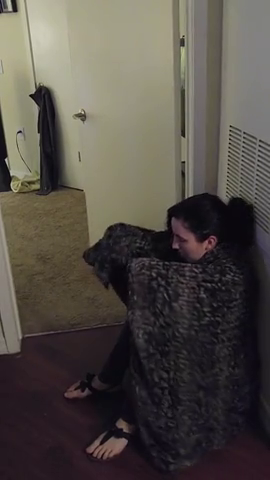

['not_looking_at', 'in', 'covered_by', 'not_looking_at', 'in', 'covered_by', 'not_looking_at', 'beneath', 'sitting_on']


NetworkXError: draw_networkx_edge_labels does not support multiedges.

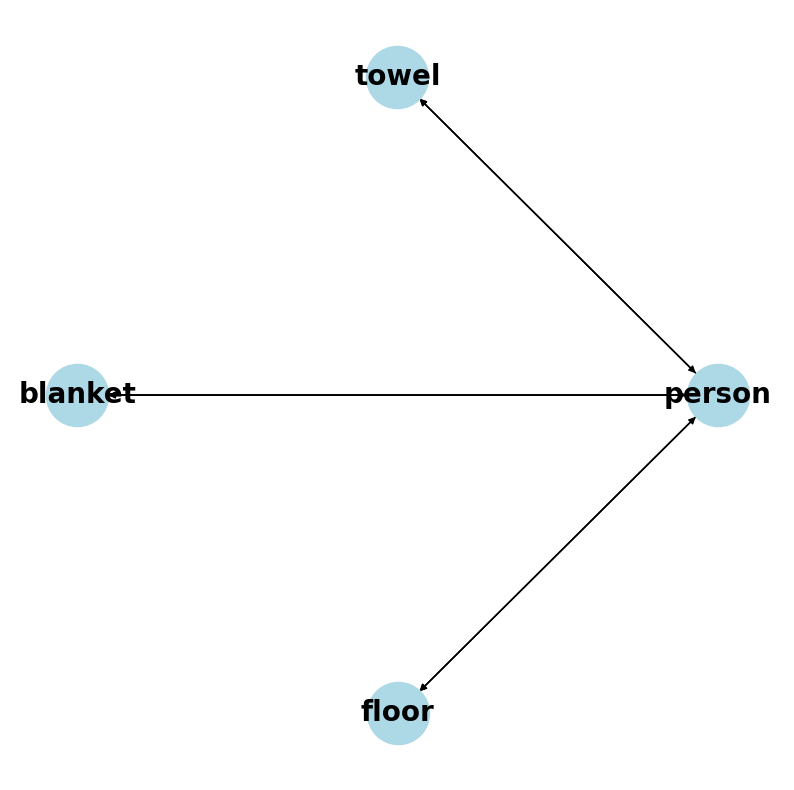

In [36]:
j = 10
i = goodies[j]
id, img, scene_graph, action_labels, constraint, truth_value = ag[i]
label = ag.verb_classes[np.argmax(joint_preds[i][1])]  

joint_top5 = np.argsort(joint_preds[i][0])[-5:][::-1]
neural_top5 = np.argsort(neural_preds[i][0])[-5:][::-1]
rules_top5 = np.argsort(rules_preds[i][0])[-5:][::-1]   

jclasses = [ag.verb_classes[j] for j in joint_top5]
nclasses = [ag.verb_classes[j] for j in neural_top5]
rclasses = [ag.verb_classes[j] for j in rules_top5]

print('label', label, 
      '\njoint', jclasses, 
      '\nneural', nclasses, 
      '\nrules', rclasses)
img
display(img)
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
print([ag.relationship_classes[e] for e in scene_graph.edge_type])
show_pyg_graph(scene_graph, ag.object_classes, ag.relationship_classes, layout='circular', ax=ax)

(4264, 2, 30)

TypeError: Image data of dtype <U20 cannot be converted to float

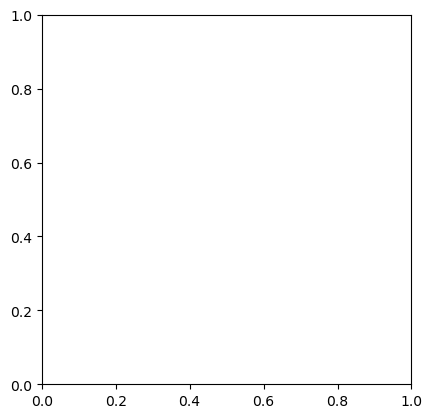

In [19]:
from util.rule_utils import apply_rules

rules_name = 'pre_rules'
prolog_folder = 'prolog/ag/'    
position = 'pre'
data_split = split
mode = 'soft'


constraints, truth_values = apply_rules(rules_name, 
    os.path.join(prolog_folder, position, 'learned_rules'),
    os.path.join(prolog_folder, position, f'{data_split}_bk.pl'),
    len(ag), ag.verb_classes,
    mode=mode,
    priors=ag.verb_priors)


print(len(ag))

print(constraints.shape)

Applying learned rules-----------------
rules_name: pre_rules
bk_file: prolog/ag/pre/val_bk.pl
5851
(5851, 30)


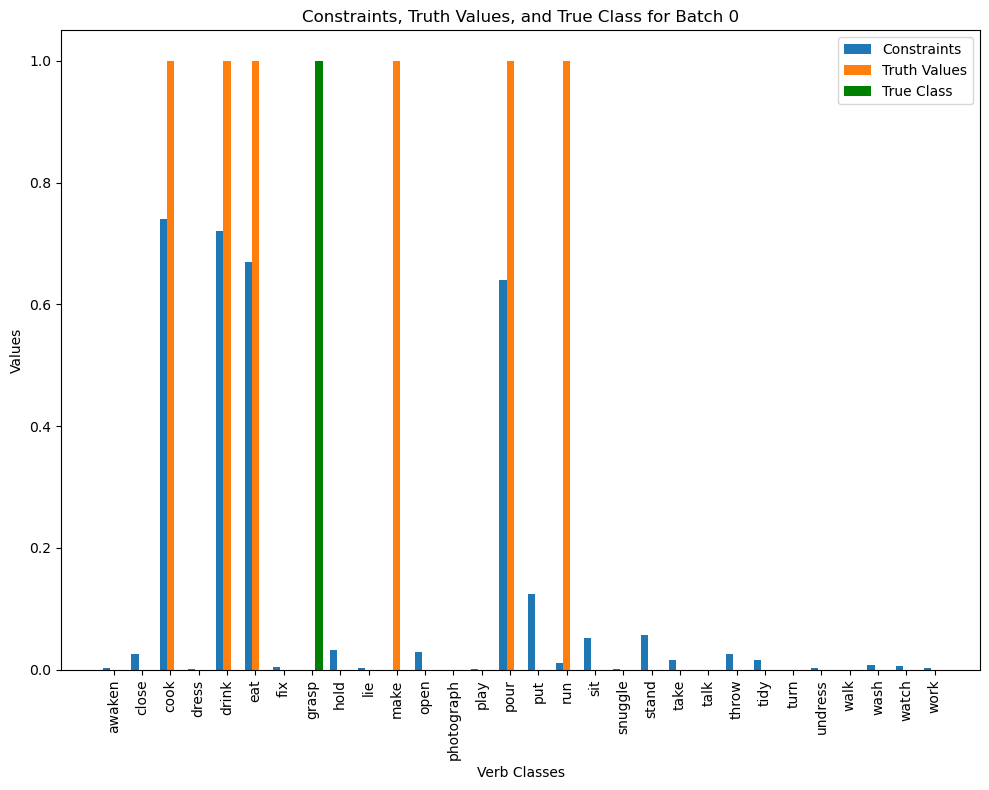

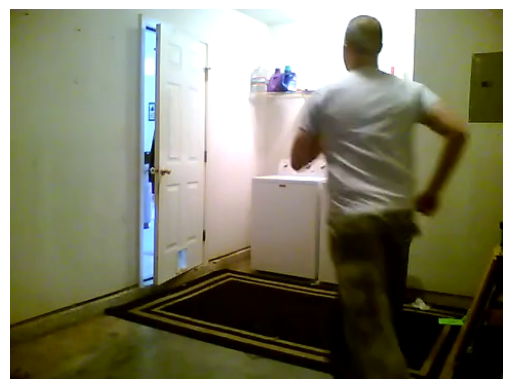

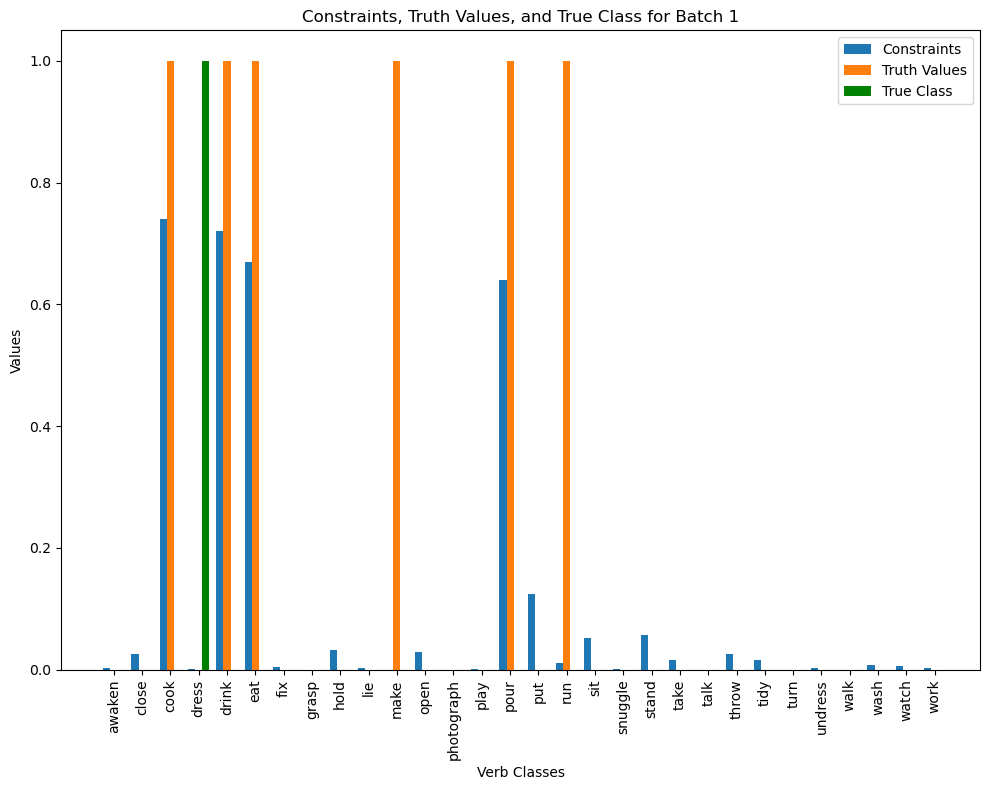

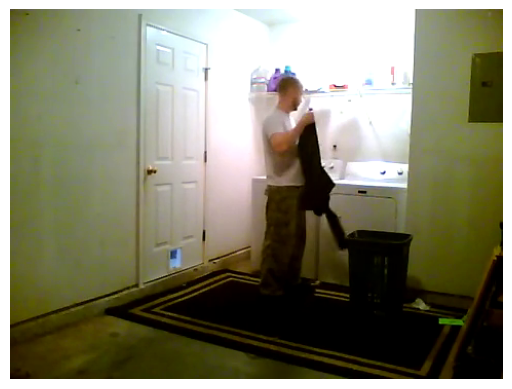

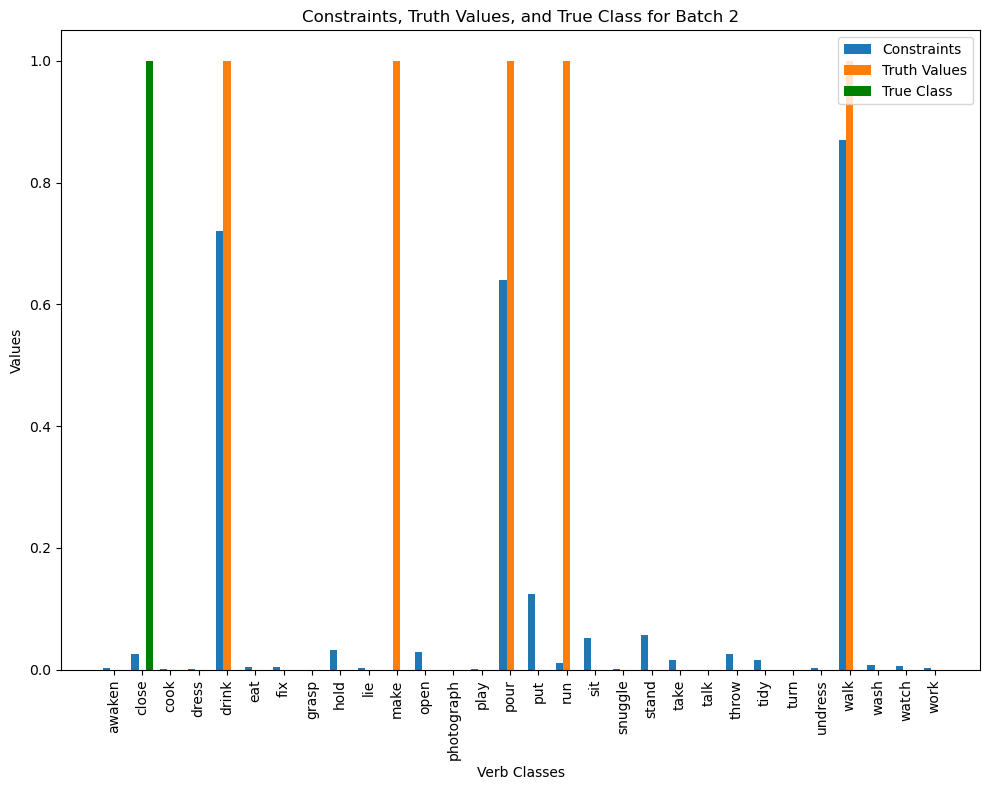

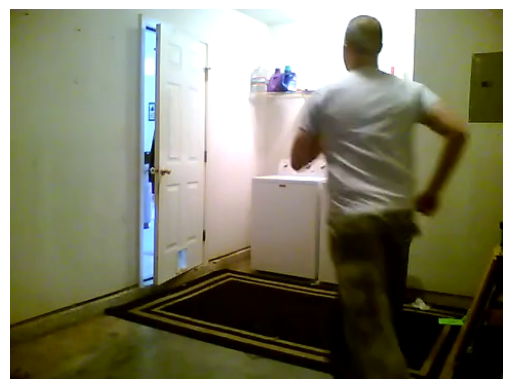

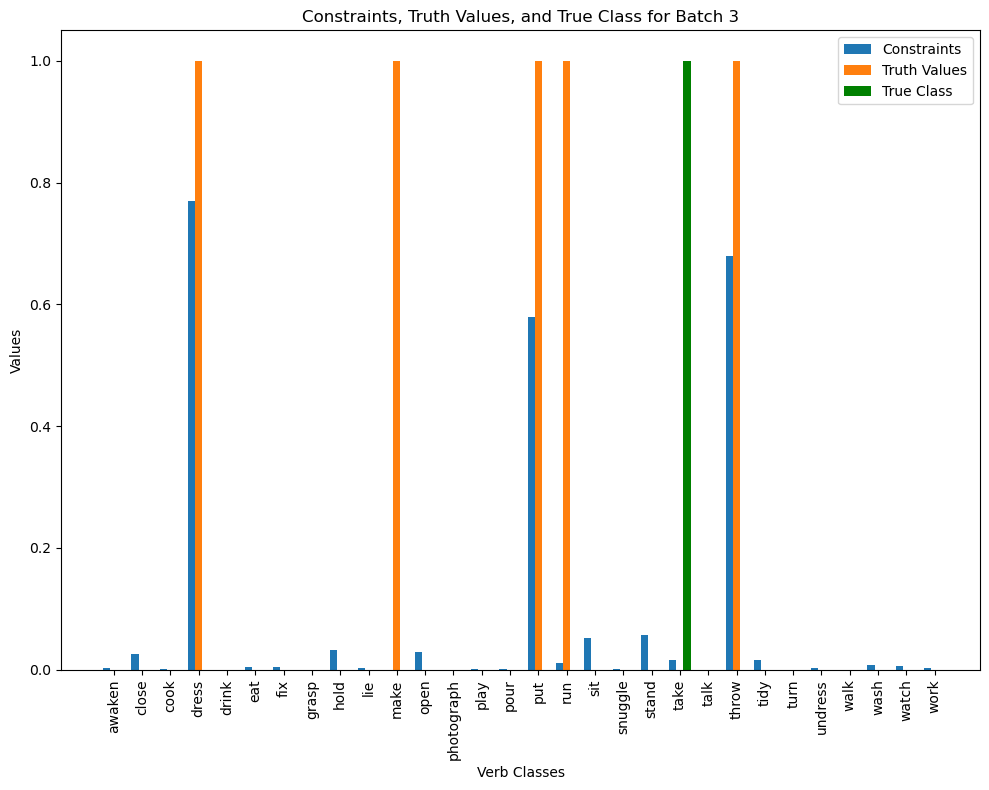

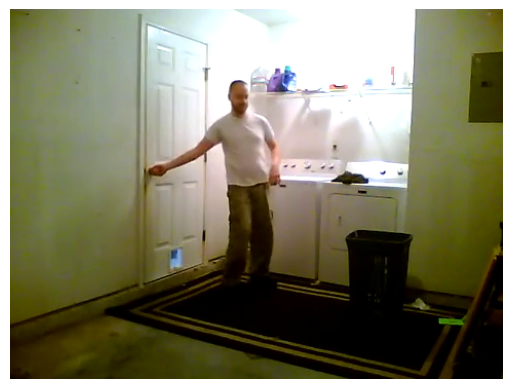

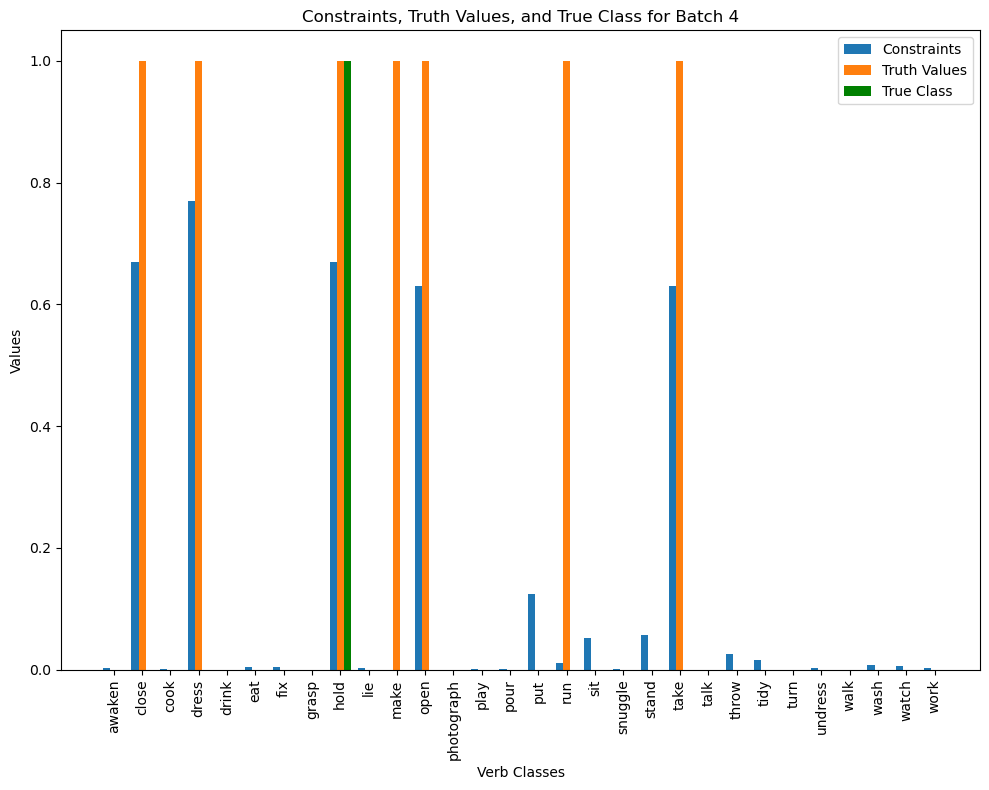

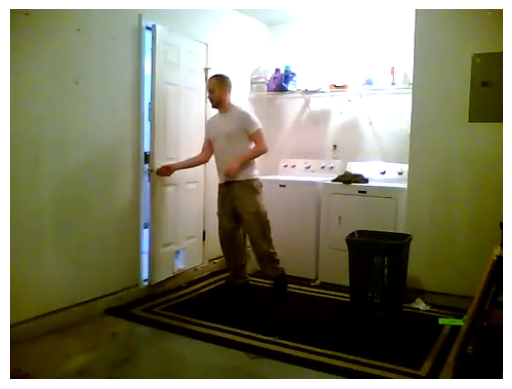

In [41]:
loader = DataLoader(ag, batch_size=5, collate_fn=ag.verb_pred_collate, num_workers=16, shuffle=False)
for i, data in enumerate(loader):
    id, image, scene_graph, action_labels, constraint, truth_value = data
    verbs = [ag.action_verb_obj_map[torch.argmax(action_label).item()][0] for action_label in action_labels]

    verb_classes = ag.verb_classes

    for batch_idx in range(len(data[0])):
        fig, ax = plt.subplots(figsize=(10, 8))

        bar_width = 0.25
        index = np.arange(len(verb_classes))

        ax.bar(index, constraints[batch_idx], bar_width, label='Constraints')
        ax.bar(index + bar_width, truth_values[batch_idx], bar_width, label='Truth Values')

        # Highlight the true class
        true_class_index = torch.argmax(action_labels[batch_idx]).item()
        ax.bar(index[true_class_index] + 2 * bar_width, 1, bar_width, color='green', label='True Class')

        ax.set_title(f'Constraints, Truth Values, and True Class for Batch {batch_idx}')
        ax.set_xlabel('Verb Classes')
        ax.set_ylabel('Values')
        ax.set_xticks(index + bar_width)
        ax.set_xticklabels(verb_classes, rotation=90)
        ax.legend()

        plt.tight_layout()
        plt.show()

        original_image = ag[batch_idx][1]
        plt.imshow(original_image)
        plt.axis('off')
        plt.show()
    break


DWHPO.mp4/000127.png
DWHPO.mp4/000253.png


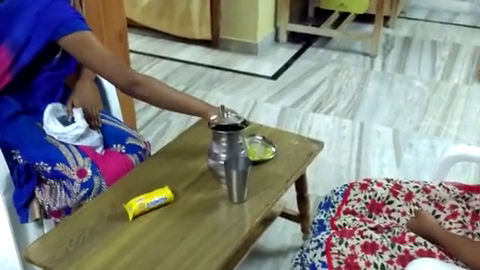

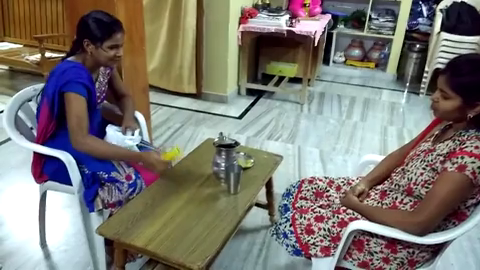

In [3]:
pre_data, post_data = ag[350]

pre_id = pre_data[0]
post_id = post_data[0]

print(pre_id)
print(post_id)

pre_image = pre_data[1]
post_image = post_data[1]

display(pre_image)
display(post_image)

[<PIL.Image.Image image mode=RGB size=480x270 at 0x78F7FD26A9D0>, <PIL.Image.Image image mode=RGB size=480x270 at 0x78F7AC2D74F0>, <PIL.Image.Image image mode=RGB size=480x270 at 0x78F7AC2D7550>, <PIL.Image.Image image mode=RGB size=480x270 at 0x78F7AC2D7580>, <PIL.Image.Image image mode=RGB size=480x270 at 0x78F7E521B220>, <PIL.Image.Image image mode=RGB size=480x270 at 0x78F7AC06E190>, <PIL.Image.Image image mode=RGB size=480x270 at 0x78F7AC2D7520>, <PIL.Image.Image image mode=RGB size=480x270 at 0x78F7AC2D7430>, <PIL.Image.Image image mode=RGB size=480x270 at 0x78F7AC2D74C0>, <PIL.Image.Image image mode=RGB size=480x270 at 0x78F7AC2D72E0>, <PIL.Image.Image image mode=RGB size=480x270 at 0x78F7AC2D71F0>, <PIL.Image.Image image mode=RGB size=480x270 at 0x78F7AC06E040>, <PIL.Image.Image image mode=RGB size=480x270 at 0x78F7E521B160>, <PIL.Image.Image image mode=RGB size=480x270 at 0x78F7AC06E0D0>, <PIL.Image.Image image mode=RGB size=480x270 at 0x78F7E521B070>, <PIL.Image.Image image m

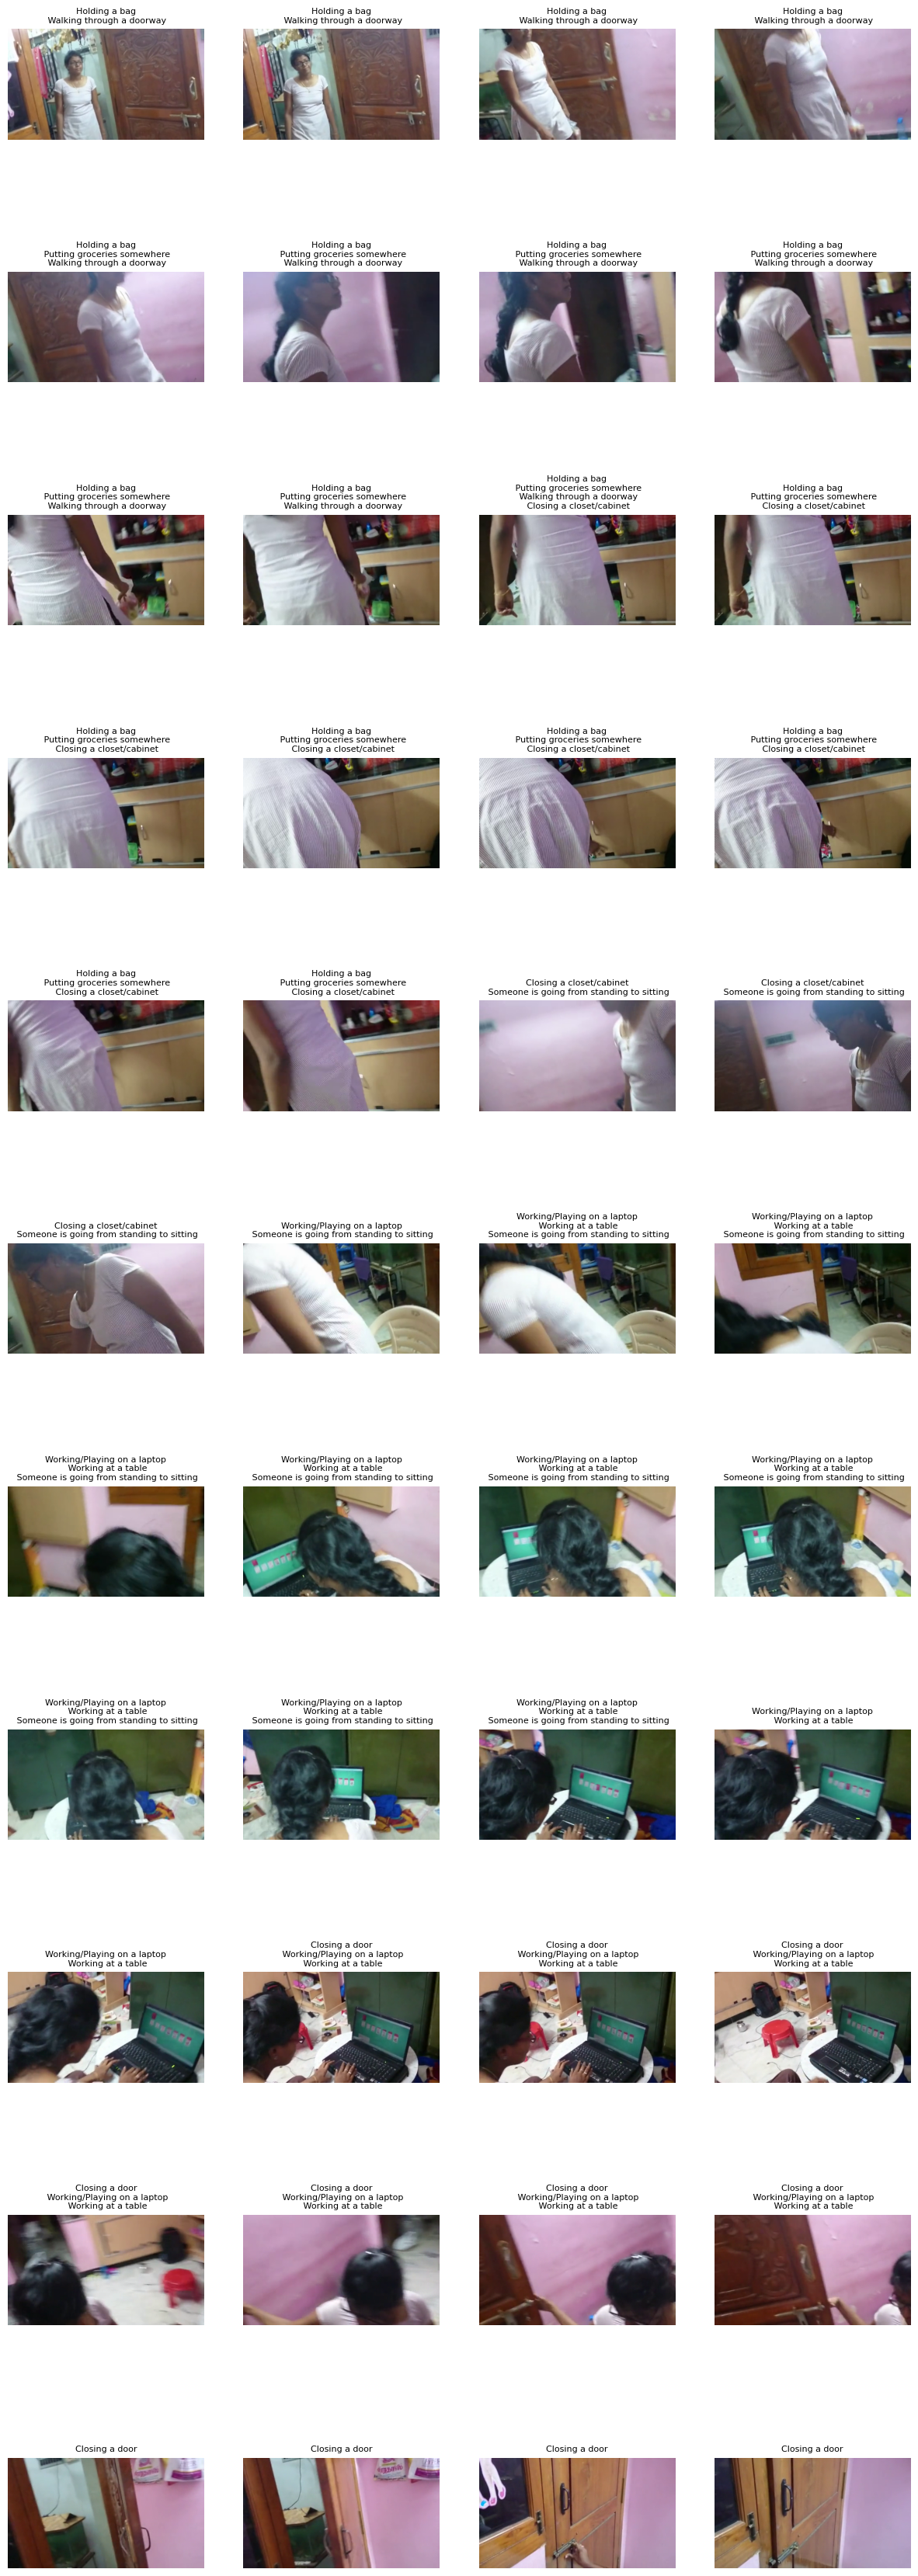

In [4]:
import matplotlib.pyplot as plt
from PIL import Image
import os

def display_video_frames(video_id, root, action_df, limit=10, col=5, row_height=5, multi_label=False):
    images = []
    captions = []
    vid_dir = os.path.join(root, 'frames', f'{video_id}.mp4')
    frame_files = sorted(os.listdir(vid_dir))[:limit]  # Get all files up to the limit
    for frame_file in frame_files:
        image_path = os.path.join(vid_dir, frame_file)
        image = Image.open(image_path).convert('RGB')
        images.append(image)
        
        # Extract frame index from the file name
        frame_idx = int(os.path.splitext(frame_file)[0])
        
        # Check if there are actions associated with this frame
        action_rows = action_df[(action_df['vid'] == video_id) & 
                                ((action_df['pre_frame'] <= frame_idx) & (action_df['post_frame'] >= frame_idx))]
        if not action_rows.empty:
            if multi_label:
                actions = action_rows['action'].values
                action_names = [ag.action_classes[a] for a in actions]
                captions.append('\n'.join(action_names))
            else:
                action_names = [ag.action_classes[int(action)] for action in action_rows['action'].values]
                captions.append('\n '.join(action_names))
        else:
            captions.append('No action')
    print(images)
    
    rows = (len(images) + col - 1) // col  # Calculate the number of rows needed
    fig, axes = plt.subplots(rows, col, figsize=(15, row_height * rows))
    axes = axes.flatten()  # Flatten the axes array for easy iteration
    for ax, img, caption in zip(axes, images, captions):
        ax.imshow(img)
        ax.set_title(caption, fontsize=8)
        ax.axis('off')
    for ax in axes[len(images):]:  # Turn off any unused subplots
        ax.axis('off')
    plt.show()

# Example usage
video_id = '00NN7'
#video_id = '001YG'
#video_id = 'WLOCV'
#video_id = '46GP8'
#video_id = 'N11GT'
#video_id = 'KRF68'
#video_id = 'MCQO5'
#video_id = 'JSUF4'
#video_id = '8WJIR'
#video_id = 'SX0HE'
#video_id = 'BDFDE'
#video_id = '3ZHEX'
#video_id = 'OOWJ9'


display_video_frames(video_id, root, ag.df, limit=100, col=4, row_height=4, multi_label=False)

In [111]:
with open(os.path.join(root, 'annotations/Charades/Charades_v1_train.csv'), 'r') as f:
    raw_df = pd.read_csv(f)

# Split each row into one row per action, and split each action into its id, start and end time
def split_actions(row):
    if isinstance(row['actions'], str):
        actions = row['actions'].split(';')
    else:
        actions = []
    split_rows = []
    for action in actions:
        action_id, start_time, end_time = action.split()
        action_id = ag.action_mapper[int(action_id[1:])]
        if action_id is not None:
            action_name = ag.action_classes[action_id]
        else:
            action_name = 'unknown'
        split_rows.append({
            'id': row['id'],
            'action_id': action_id,
            'action_name': action_name,
            'start_time': float(start_time),
            'end_time': float(end_time),
            'frame_count': row['frame_count'],
            'length': row['length'],
            'objects': row['objects']
        })
    return split_rows

# Count the frames for each video and add this count as a new column to the df
def count_frames(video_id, root):
    vid_dir = os.path.join(root, 'frames', f'{video_id}.mp4')
    if os.path.exists(vid_dir):
        return len(os.listdir(vid_dir))
    else:
        return 0

pd.options.display.max_colwidth = 1000
raw_df['frame_count'] = raw_df['id'].apply(lambda x: count_frames(x, root))

# Apply the split_actions function to each row and create a new DataFrame
split_rows = []
for _, row in raw_df.iterrows():
    split_rows.extend(split_actions(row))

split_df = pd.DataFrame(split_rows)
#split_df[split_df['id'] == '001YG'].iloc[100:120]
display(split_df)
myaction_vid_ids = split_df[split_df['action_id']==149]['id'].unique()
#print(myaction_vid_ids)

myobject_vid_ids = split_df[split_df['objects'].str.contains('sandwhich', na=False)]['id'].unique()
print(myobject_vid_ids)


,id,action_id,action_name,start_time,end_time,frame_count,length,objects
0,46GP8,90.0,Watching/Looking outside of a window,11.9,21.2,10,24.83,food;stove;window
1,46GP8,143.0,Someone is cooking something,0.0,12.6,10,24.83,food;stove;window
2,N11GT,95.0,Holding a broom,8.6,14.2,20,18.33,blanket;broom;floor
3,N11GT,74.0,Tidying up a blanket/s,0.0,11.7,20,18.33,blanket;broom;floor
4,N11GT,124.0,Tidying something on the floor,0.0,15.2,20,18.33,blanket;broom;floor
...,...,...,...,...,...,...,...,...
49804,PG1ID,50.0,Watching a laptop or something on a laptop,0.0,33.0,20,32.08,broom;laptop;something
49805,PG1ID,51.0,Working/Playing on a laptop,0.0,33.0,20,32.08,broom;laptop;something
49806,PG1ID,97.0,Taking a broom from somewhere,19.5,26.4,20,32.08,broom;laptop;something
49807,PG1ID,146.0,Someone is going from standing to sitting,20.5,30.6,20,32.08,broom;laptop;something


['SGUK6' 'B5226' 'A7BUX' 'NHB5N' '1C6P3' 'TS75H' '7WOTM' 'WE2PF']


In [ ]:
display_video_frames(myobject_vid_ids[2], root, ag.df, limit=100, col=1, row_height=9, multi_label=False)

                   Top 1 Acc  Top 5 Acc  Precision  Recall
Backbone only           21.4       49.6       15.0    23.2
Non-probabilistic       22.0       52.7       15.5    23.6
Rules only              22.2       78.5       19.9    27.4
Integrated              28.5       77.7       22.9    31.0


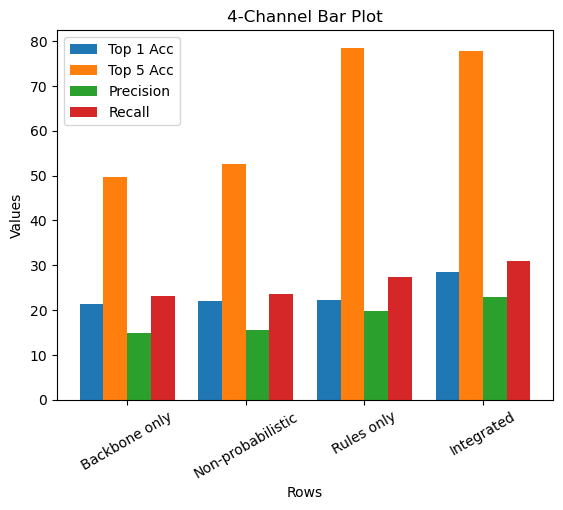

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Create a 4x4 table with placeholder data
data = {
    'Top 1 Acc': [21.4, 22.0, 22.2, 28.5],
    'Top 5 Acc': [49.6, 52.7, 78.5, 77.7],
    'Precision': [15.0, 15.5, 19.9, 22.9],
    'Recall': [23.2, 23.6, 27.4, 31.0]
}

# Convert the data into a DataFrame
df = pd.DataFrame(data, index=['Backbone only', 'Non-probabilistic', 'Rules only', 'Integrated'])
print(df)

# Create a 4-channel bar plot using the data
fig, ax = plt.subplots()

bar_width = 0.2
index = np.arange(len(df))

bar1 = ax.bar(index, df['Top 1 Acc'], bar_width, label='Top 1 Acc')
bar2 = ax.bar(index + bar_width, df['Top 5 Acc'], bar_width, label='Top 5 Acc')
bar3 = ax.bar(index + 2 * bar_width, df['Precision'], bar_width, label='Precision')
bar4 = ax.bar(index + 3 * bar_width, df['Recall'], bar_width, label='Recall')

ax.set_xlabel('Rows')
ax.set_ylabel('Values')
ax.set_title('4-Channel Bar Plot')
ax.set_xticks(index + 1.5 * bar_width)
ax.set_xticklabels(df.index, rotation=30)  # Tilt labels at a 30 degree angle
ax.legend()

plt.show()


Original Data:
                   Top 1 Acc  Top 5 Acc  Precision  Recall
Backbone only           21.4       49.6       15.0    23.2
Non-probabilistic       22.0       52.7       15.5    23.6
Rules only              22.2       78.5       19.9    27.4
Integrated              28.5       77.7       22.9    31.0

Normalized Data:
                   Top 1 Acc  Top 5 Acc  Precision    Recall
Backbone only       1.000000   1.000000   1.000000  1.000000
Non-probabilistic   1.028037   1.062500   1.033333  1.017241
Rules only          1.037383   1.582661   1.326667  1.181034
Integrated          1.331776   1.566532   1.526667  1.336207


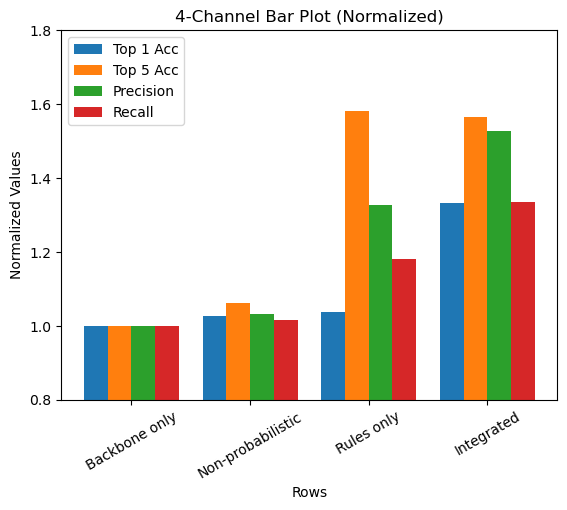

In [30]:
import matplotlib.pyplot as plt
import numpy as np

# Create a 4x4 table with placeholder data
data = {
    'Top 1 Acc': [21.4, 22.0, 22.2, 28.5],
    'Top 5 Acc': [49.6, 52.7, 78.5, 77.7],
    'Precision': [15.0, 15.5, 19.9, 22.9],
    'Recall': [23.2, 23.6, 27.4, 31.0]
}

# Convert the data into a DataFrame
df = pd.DataFrame(data, index=['Backbone only', 'Non-probabilistic', 'Rules only', 'Integrated'])
print("Original Data:")
print(df)

# Normalize the values relative to 'Backbone only'
df_normalized = df.div(df.loc['Backbone only'])
print("\nNormalized Data:")
print(df_normalized)

# Create a 4-channel bar plot using the normalized data
fig, ax = plt.subplots()

bar_width = 0.2
index = np.arange(len(df_normalized))

bar1 = ax.bar(index, df_normalized['Top 1 Acc'], bar_width, label='Top 1 Acc')
bar2 = ax.bar(index + bar_width, df_normalized['Top 5 Acc'], bar_width, label='Top 5 Acc')
bar3 = ax.bar(index + 2 * bar_width, df_normalized['Precision'], bar_width, label='Precision')
bar4 = ax.bar(index + 3 * bar_width, df_normalized['Recall'], bar_width, label='Recall')

ax.set_xlabel('Rows')
ax.set_ylabel('Normalized Values')
ax.set_title('4-Channel Bar Plot (Normalized)')
ax.set_xticks(index + 1.5 * bar_width)
ax.set_xticklabels(df.index, rotation=30)  # Tilt labels at a 30 degree angle
ax.legend()

ax.set_ylim(0.8, 1.8)

plt.show()


          Method  Top 1 Acc  Top 5 Acc  Precision  Recall
0  Backbone only       21.4       49.6       15.0    23.2
1     Rules only       22.2       78.5       19.9    27.4
2     Integrated       28.5       77.7       22.9    31.0
Method     Backbone only  Rules only  Integrated
Top 1 Acc           21.4        22.2        28.5
Top 5 Acc           49.6        78.5        77.7
Precision           15.0        19.9        22.9
Recall              23.2        27.4        31.0


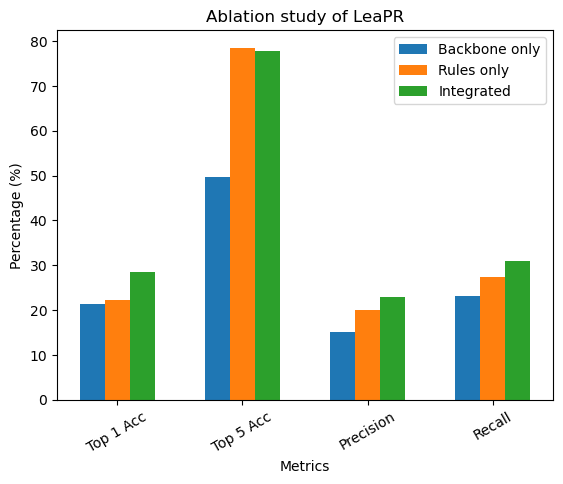

In [81]:
import matplotlib.pyplot as plt
import numpy as np

# Create a 3x4 table with placeholder data
data = {
    'Method': ['Backbone only', 'Rules only', 'Integrated'],
    'Top 1 Acc': [21.4, 22.2, 28.5],
    'Top 5 Acc': [49.6, 78.5, 77.7],
    'Precision': [15.0, 19.9, 22.9],
    'Recall': [23.2, 27.4, 31.0]
}

# Convert the data into a DataFrame
df = pd.DataFrame(data)
print(df)

# Transpose the DataFrame to group by metric
df_transposed = df.set_index('Method').T
print(df_transposed)

# Create a 3-channel bar plot using the transposed data
fig, ax = plt.subplots()

bar_width = 0.2
index = np.arange(len(df_transposed))

bar1 = ax.bar(index, df_transposed['Backbone only'], bar_width, label='Backbone only')
bar2 = ax.bar(index + bar_width, df_transposed['Rules only'], bar_width, label='Rules only')
bar3 = ax.bar(index + 2 * bar_width, df_transposed['Integrated'], bar_width, label='Integrated')

ax.set_xlabel('Metrics')
ax.set_ylabel('Percentage (%)')
ax.set_title('Ablation study of LeaPR')
ax.set_xticks(index + bar_width)
ax.set_xticklabels(df_transposed.index, rotation=30)  # Tilt labels at a 30 degree angle
ax.legend()

plt.show()


              Method  Top 1 Acc  Top 5 Acc  Precision  Recall
0      Backbone only       21.4       49.6       15.0    23.2
1  Non-probabilistic       22.0       52.7       15.5    23.6
2         Rules only       22.2       78.5       19.9    27.4
3         Integrated       28.5       77.7       22.9    31.0
                   Top 1 Acc  Top 5 Acc  Precision    Recall
Method                                                      
Backbone only       1.000000   1.000000   1.000000  1.000000
Non-probabilistic   1.028037   1.062500   1.033333  1.017241
Rules only          1.037383   1.582661   1.326667  1.181034
Integrated          1.331776   1.566532   1.526667  1.336207
Method     Backbone only  Non-probabilistic  Rules only  Integrated
Top 1 Acc            1.0           1.028037    1.037383    1.331776
Top 5 Acc            1.0           1.062500    1.582661    1.566532
Precision            1.0           1.033333    1.326667    1.526667
Recall               1.0           1.017241    1.181

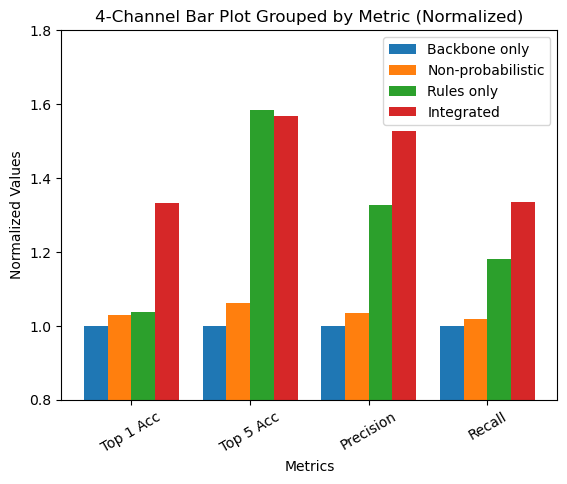

In [29]:

import matplotlib.pyplot as plt
import numpy as np

# Create a 4x4 table with placeholder data
data = {
    'Method': ['Backbone only', 'Non-probabilistic', 'Rules only', 'Integrated'],
    'Top 1 Acc': [21.4, 22.0, 22.2, 28.5],
    'Top 5 Acc': [49.6, 52.7, 78.5, 77.7],
    'Precision': [15.0, 15.5, 19.9, 22.9],
    'Recall': [23.2, 23.6, 27.4, 31.0]
}

# Convert the data into a DataFrame
df = pd.DataFrame(data)
print(df)

# Normalize the data relative to the 'Backbone only' method
df_normalized = df.set_index('Method').div(df.set_index('Method').loc['Backbone only'])
print(df_normalized)

# Transpose the normalized DataFrame to group by metric
df_transposed = df_normalized.T
print(df_transposed)

# Create a 4-channel bar plot using the transposed normalized data
fig, ax = plt.subplots()

bar_width = 0.2
index = np.arange(len(df_transposed.columns))

bar1 = ax.bar(index, df_transposed['Backbone only'], bar_width, label='Backbone only')
bar2 = ax.bar(index + bar_width, df_transposed['Non-probabilistic'], bar_width, label='Non-probabilistic')
bar3 = ax.bar(index + 2 * bar_width, df_transposed['Rules only'], bar_width, label='Rules only')
bar4 = ax.bar(index + 3 * bar_width, df_transposed['Integrated'], bar_width, label='Integrated')

ax.set_xlabel('Metrics')
ax.set_ylabel('Normalized Values')
ax.set_title('4-Channel Bar Plot Grouped by Metric (Normalized)')
ax.set_xticks(index + 1.5 * bar_width)
ax.set_xticklabels(df_transposed.index, rotation=30)  # Tilt labels at a 30 degree angle
ax.legend()

# Adjust the y-axis range to make differences more pronounced
ax.set_ylim(0.8, 1.8)

plt.show()


In [21]:
import pandas as pd
# Create a sample DataFrame
data = {
    'A': [1, 2, 3, 4],
    'B': [10, 20, 30, 40],
    'C': [100, 200, 300, 400]
}
df = pd.DataFrame(data)
print("Original DataFrame:")
print(df)

# Define a function to check if the sum of a row is even
def is_row_sum_even(row):
    print(row)
    return row.sum() % 2 == 0

print('======================================')


mask = df.apply(is_row_sum_even, axis=1)
print(df)
final = df[mask]
print(final)

'''
# Apply the function to each row and create a subset of the DataFrame with rows that sum to an even number
even_sum_df = df[)]
print("\nSubset of DataFrame with rows that sum to an even number:")
print(even_sum_df)

'''

Original DataFrame:
   A   B    C
0  1  10  100
1  2  20  200
2  3  30  300
3  4  40  400
A      1
B     10
C    100
Name: 0, dtype: int64
A      2
B     20
C    200
Name: 1, dtype: int64
A      3
B     30
C    300
Name: 2, dtype: int64
A      4
B     40
C    400
Name: 3, dtype: int64
   A   B    C
0  1  10  100
1  2  20  200
2  3  30  300
3  4  40  400
   A   B    C
1  2  20  200
3  4  40  400


'\n# Apply the function to each row and create a subset of the DataFrame with rows that sum to an even number\neven_sum_df = df[)]\nprint("\nSubset of DataFrame with rows that sum to an even number:")\nprint(even_sum_df)\n\n'